In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math, scipy, skimage, os
import matplotlib as mpl
import seaborn as sns

mpl.rcParams.update({
    'font.family': 'Arial',
    'font.size': 7,

    'svg.fonttype':'none',
    'pdf.fonttype': 42,

    'axes.linewidth': 0.5,

    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.minor.width': 0.5,
    'ytick.minor.width': 0.5,

    'xtick.major.size': 2,
    'ytick.major.size': 2,
    'xtick.major.pad': 1,
    'ytick.major.pad': 1,

    'axes.labelpad': 1
})

In [3]:
from xint_toolbox import piv_lab_rearrange, create_folder

In [10]:
example_folder = 'XIN211117_LaserCutter\\_36_cut_from-ac-across-cb\\'

In [11]:
movie = skimage.io.imread(example_folder + '36_cut_from_ac_across_cb_roi1_f70-354.tif')
Piv = piv_lab_rearrange(folder=example_folder + 'pivlabtxt', t_interval=0.2, pixel_size=0.34)

In [12]:
frames, ys, xs = movie.shape

piv_x, piv_y = Piv.x, Piv.y
piv_u, piv_v= Piv.u, Piv.v
piv_vel = Piv.vel

piv_u_unit, piv_v_unit = piv_u/piv_vel, piv_v/piv_vel

piv_x_step = (piv_x[1,0] - piv_x[0,0]) / 2
piv_y_step = (piv_y[0,1] - piv_y[0,0]) / 2

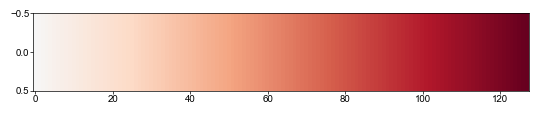

In [13]:
# new cmap
new_reds_cmap = mpl.colors.ListedColormap(mpl.colormaps['RdBu'](np.linspace(0.5,0,1024)))
plt.imshow([np.arange(128)], aspect=20, cmap=new_reds_cmap)
plt.show()

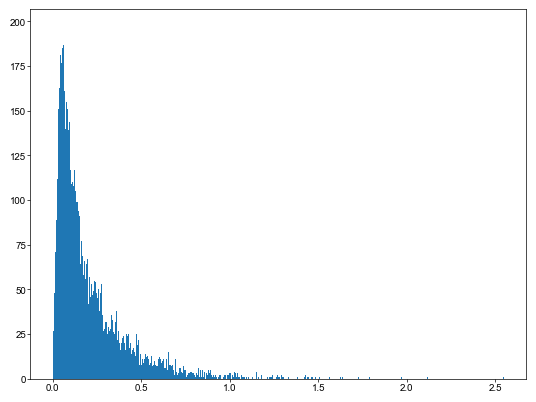

In [14]:
_ = plt.hist(piv_vel[59:120].flatten(), bins=1024)
piv_vel_levels= np.linspace(0,8,128)

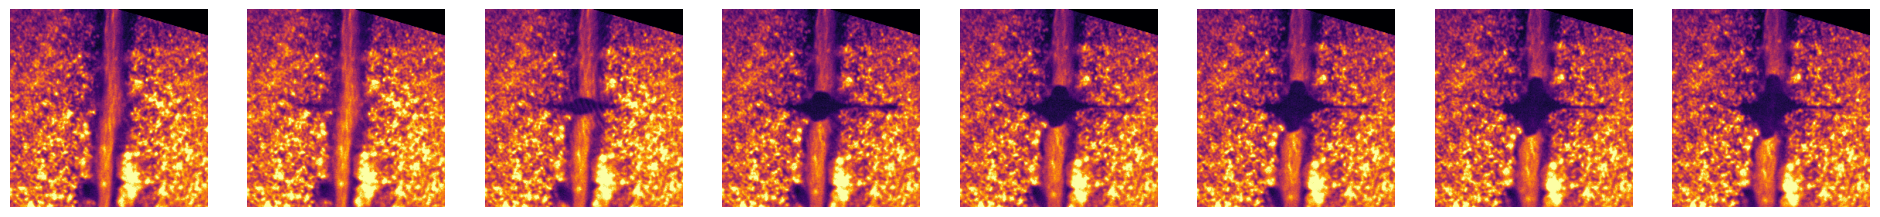

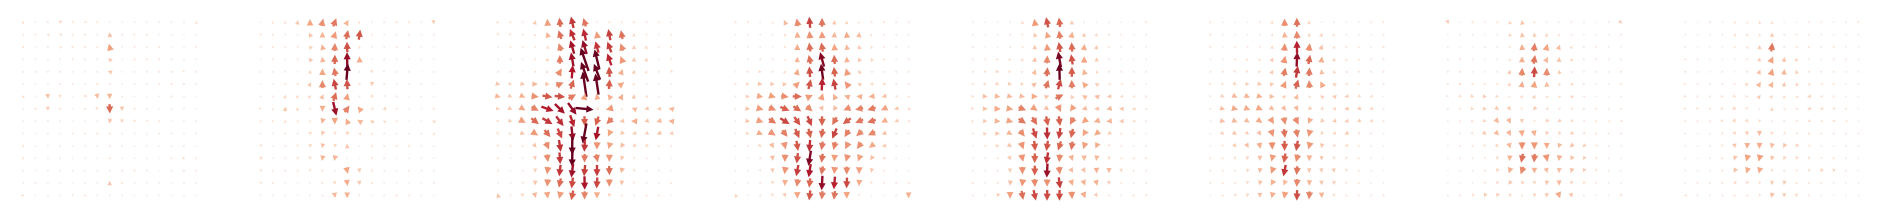

In [15]:
fig, axs = plt.subplots(1,8, figsize=[24, 3])
for ax, frame in zip(axs, np.array([69,75,81,87,93,99,105,111])-1):
    ax.imshow(movie[frame], cmap='inferno', vmin=12, vmax=80)
    ax.set_axis_off()
plt.show()

fig, axs = plt.subplots(1,8, figsize=[24, 3])
for ax, frame in zip(axs, np.array([69,75,81,87,93,99,105,111])-1):
    # ax.imshow(movie[frame], cmap='inferno', vmin=12, vmax=80)
    ax.set_axis_off()
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')

    # im1 = ax.imshow(piv_vel[frame].T, extent=[piv_x[0,0] - piv_x_step, piv_x[-1,0] + piv_x_step, piv_y[0,-1] - piv_y_step, piv_y[0,0] + piv_y_step],
    #                 cmap=new_reds_cmap, vmin=0, vmax=2, interpolation='None')
    ax.set_xlim(0,xs)
    ax.set_ylim(ys,0)
    
    stride = 1
    orientation_cmap = new_reds_cmap #plt.colormaps["Greys"]
    orientation_colors = piv_vel[frame]/1
    ax.quiver(piv_x[::stride, ::stride].flatten(), piv_y[::stride, ::stride].flatten(),
              piv_u[frame][::stride, ::stride].flatten(), -piv_v[frame][::stride, ::stride].flatten(),
            # piv_u_unit[frame][::stride, ::stride].flatten(), -piv_v_unit[frame][::stride, ::stride].flatten(),
              scale = 12, color=orientation_cmap(orientation_colors[::stride, ::stride].flatten()),
              width = 0.012, pivot = 'mid', headwidth =3, headlength = 3, headaxislength = 3)
plt.savefig(example_folder + 'long_cut_piv_to_show.svg')
plt.show()

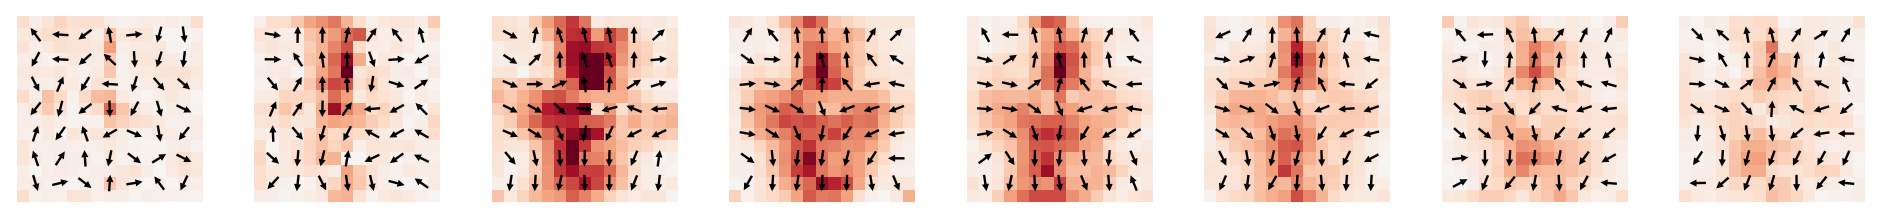

In [33]:
fig, axs = plt.subplots(1,8, figsize=[24, 3])
for ax, frame in zip(axs, np.array([69,75,81,87,93,99,105,111])-1):
    ax.imshow(piv_vel[frame].T, cmap=new_reds_cmap, extent=[piv_x[0,0] - piv_x_step, piv_x[-1,-1] + piv_x_step, piv_x[-1,-1] + piv_x_step, piv_x[0,0] - piv_x_step], vmin=0, vmax=1)
    ax.set_axis_off()
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')

    # im1 = ax.imshow(piv_vel[frame].T, extent=[piv_x[0,0] - piv_x_step, piv_x[-1,0] + piv_x_step, piv_y[0,-1] - piv_y_step, piv_y[0,0] + piv_y_step],
    #                 cmap=new_reds_cmap, vmin=0, vmax=2, interpolation='None')
    ax.set_xlim(0,xs)
    ax.set_ylim(ys,0)
    
    stride = 2
    stride_offset=1
    orientation_cmap = new_reds_cmap #plt.colormaps["Greys"]
    orientation_colors = piv_vel[frame]/1
    ax.quiver(piv_x[stride_offset::stride, stride_offset::stride], piv_y[stride_offset::stride, stride_offset::stride],
              piv_u_unit[frame][stride_offset::stride, stride_offset::stride], -piv_v_unit[frame][stride_offset::stride, stride_offset::stride],
            # piv_u_unit[frame][::stride, ::stride].flatten(), -piv_v_unit[frame][::stride, ::stride].flatten(),
              scale = 12, color='black',
              width = 0.012, pivot = 'mid', headwidth =3, headlength = 3, headaxislength = 3)
plt.savefig(example_folder + 'long_cut_piv_to_show_2.svg')
plt.show()